In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv(r"C:\Users\shikh\OneDrive\Desktop\AI_Banking_system\Data\01_support_tickets.csv")
df.head(5)

,ticket_id,date_created,customer_id,channel,category,sub_category,query_text,sentiment,risk_level,resolution_text,resolution_time_minutes,resolved_by,customer_satisfaction,escalated
0,TKT-10001,2023-03-13,CUST872246,Web Chat,Fraud/Unauthorized,I see a transaction of ₹{amt} I didn't m,I see a transaction of ₹999 I didn't make on 2...,Urgent,High,Unauthorized transaction reported on account. ...,28,Sneha R.,2,Yes
1,TKT-10002,2023-11-05,CUST127824,Branch,Fraud/Unauthorized,I see a transaction of ₹{amt} I didn't m,I see a transaction of ₹500 I didn't make on 1...,Neutral,High,Unauthorized transaction reported on account. ...,27,Auto-Resolved,5,No
2,TKT-10003,2023-08-05,CUST456778,Phone,Fraud/Unauthorized,I see a transaction of ₹{amt} I didn't m,"I see a transaction of ₹25,000 I didn't make o...",Neutral,High,Unauthorized transaction reported on account. ...,11,Anjali K.,2,No
3,TKT-10004,2023-01-23,CUST865179,Email,Fraud/Unauthorized,I see a transaction of ₹{amt} I didn't m,I see a transaction of ₹999 I didn't make on 1...,Confused,High,Unauthorized transaction reported on account. ...,8,Vikram P.,2,Yes
4,TKT-10005,2023-12-05,CUST338968,Phone,Fraud/Unauthorized,I see a transaction of ₹{amt} I didn't m,"I see a transaction of ₹25,000 I didn't make o...",Frustrated,High,Unauthorized transaction reported on account. ...,12,Priya S.,5,No


##Assessment and cleaning

In [47]:
df.dtypes

ticket_id                  object
date_created               object
customer_id                object
channel                    object
category                   object
sub_category               object
query_text                 object
sentiment                  object
risk_level                 object
resolution_text            object
resolution_time_minutes     int64
resolved_by                object
customer_satisfaction       int64
escalated                  object
dtype: object

In [48]:
obj_cols = df.select_dtypes(include = 'object').columns

In [49]:
obj_cols

Index(['ticket_id', 'date_created', 'customer_id', 'channel', 'category',
       'sub_category', 'query_text', 'sentiment', 'risk_level',
       'resolution_text', 'resolved_by', 'escalated'],
      dtype='object')

In [50]:
df.isnull().sum()

ticket_id                  0
date_created               0
customer_id                0
channel                    0
category                   0
sub_category               0
query_text                 0
sentiment                  0
risk_level                 0
resolution_text            0
resolution_time_minutes    0
resolved_by                0
customer_satisfaction      0
escalated                  0
dtype: int64

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
for i in obj_cols:
    print(df[i].value_counts(dropna = False))

ticket_id
TKT-10001    1
TKT-10002    1
TKT-10003    1
TKT-10004    1
TKT-10005    1
            ..
TKT-10196    1
TKT-10197    1
TKT-10198    1
TKT-10199    1
TKT-10200    1
Name: count, Length: 200, dtype: int64
date_created
2023-12-09    4
2023-08-05    3
2023-03-08    3
2023-12-15    3
2023-05-05    3
             ..
2023-04-27    1
2023-12-27    1
2023-07-22    1
2023-04-20    1
2023-05-27    1
Name: count, Length: 149, dtype: int64
customer_id
CUST872246    1
CUST127824    1
CUST456778    1
CUST865179    1
CUST338968    1
             ..
CUST958130    1
CUST311883    1
CUST153231    1
CUST908206    1
CUST777273    1
Name: count, Length: 200, dtype: int64
channel
Email         45
Branch        41
Phone         40
Web Chat      39
Mobile App    35
Name: count, dtype: int64
category
Fraud/Unauthorized    50
Loan                  50
KYC                   50
Account Access        50
Name: count, dtype: int64
sub_category
I see a transaction of ₹{amt} I didn't m    5
There's an ATM wit

Explorar=tory data analysis

In [53]:
sns.set_theme(style="whitegrid")

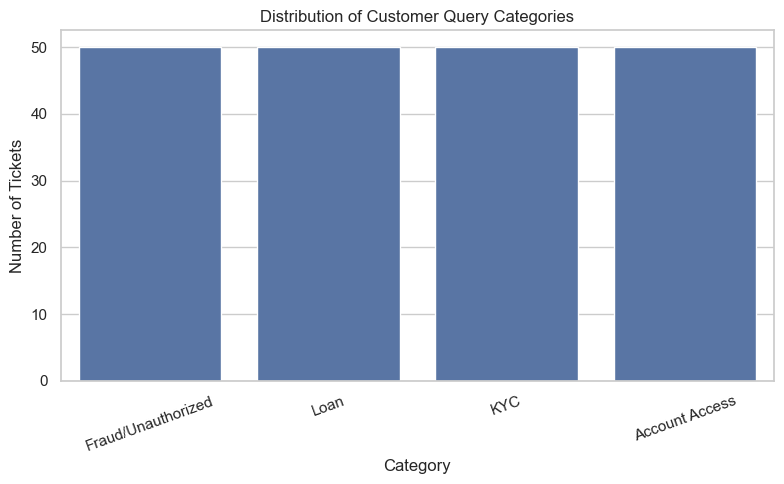

In [54]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index
)

plt.title("Distribution of Customer Query Categories")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

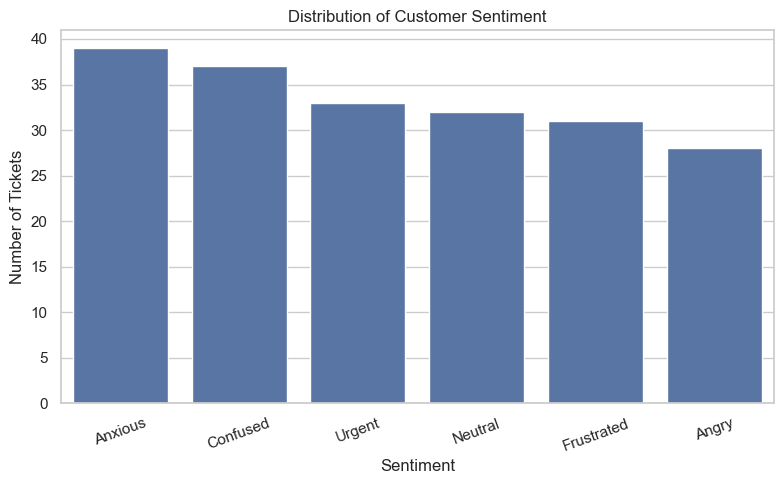

In [55]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="sentiment",
    order=df["sentiment"].value_counts().index
)

plt.title("Distribution of Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

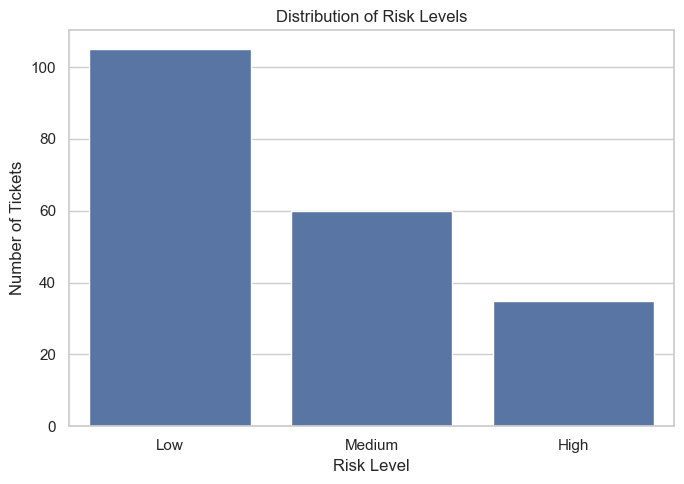

In [56]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="risk_level",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

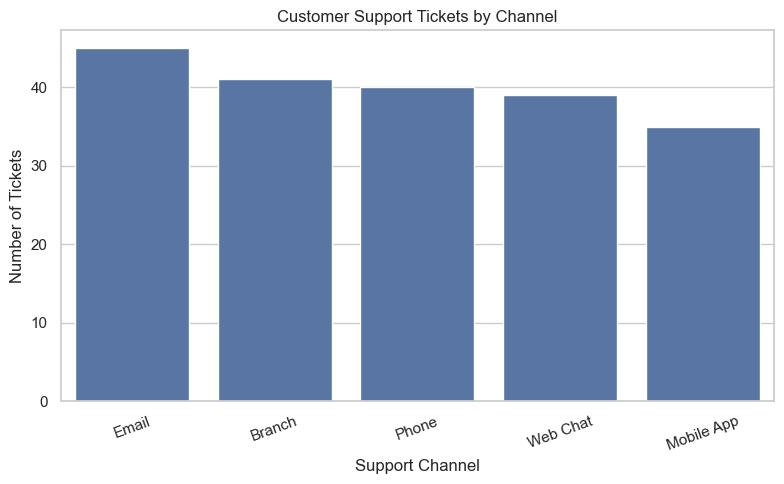

In [57]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="channel",
    order=df["channel"].value_counts().index
)

plt.title("Customer Support Tickets by Channel")
plt.xlabel("Support Channel")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

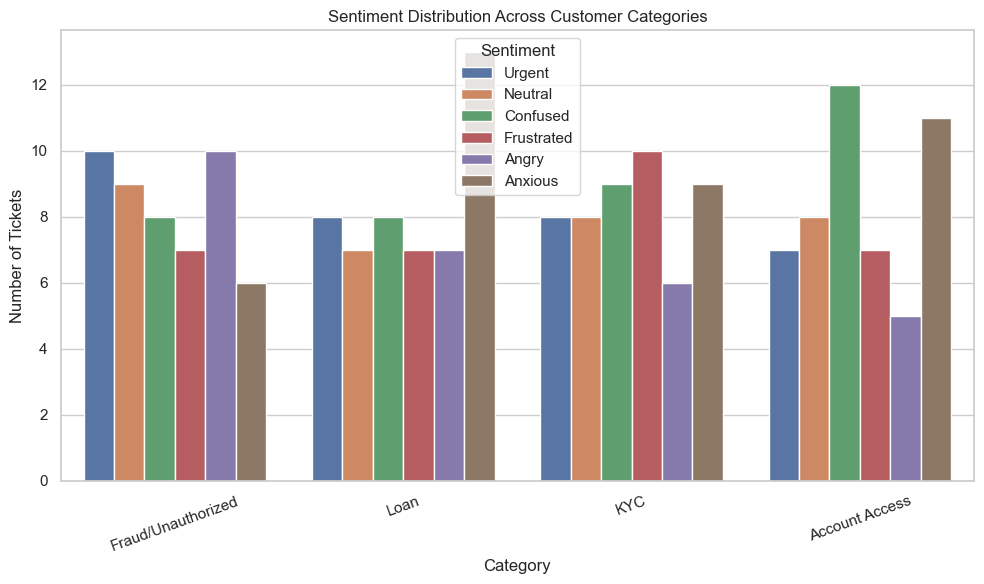

In [58]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="category",
    hue="sentiment"
)

plt.title("Sentiment Distribution Across Customer Categories")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

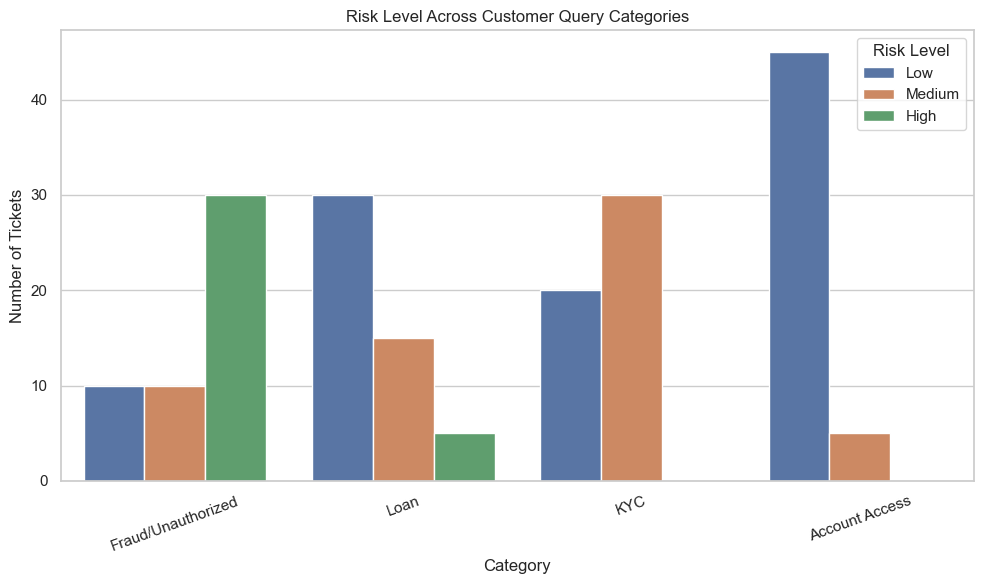

In [59]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="category",
    hue="risk_level",
    hue_order=["Low", "Medium", "High"]
)

plt.title("Risk Level Across Customer Query Categories")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.legend(title="Risk Level")
plt.tight_layout()
plt.show()

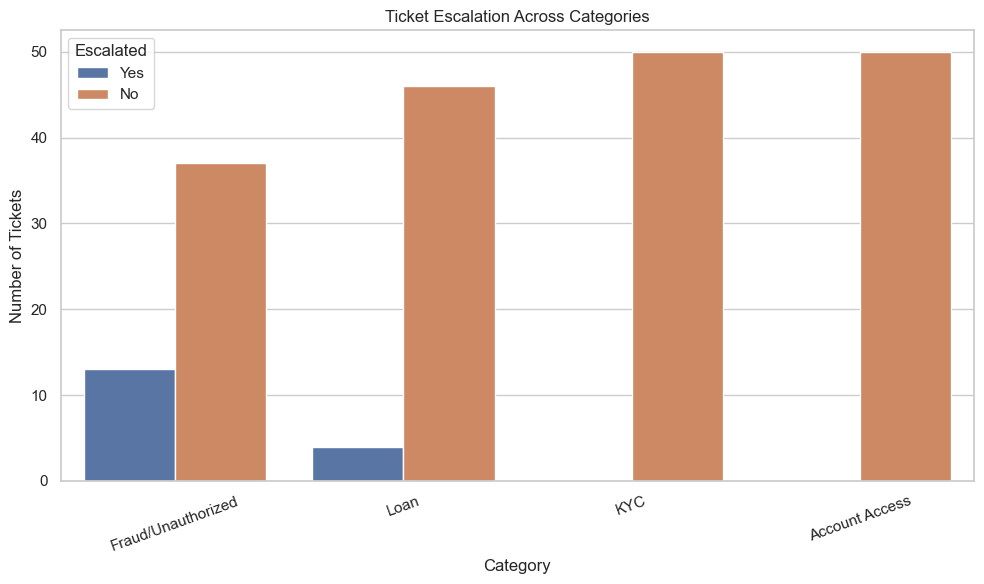

In [60]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="category",
    hue="escalated"
)

plt.title("Ticket Escalation Across Categories")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=20)
plt.legend(title="Escalated")
plt.tight_layout()
plt.show()

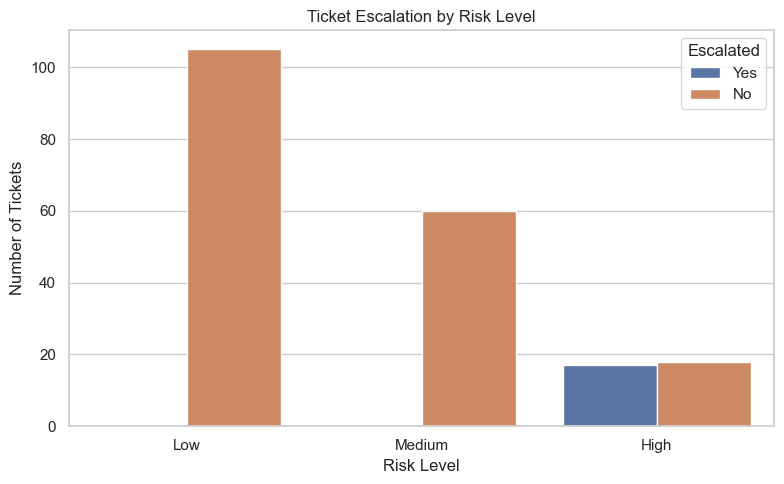

In [61]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="risk_level",
    hue="escalated",
    order=["Low", "Medium", "High"]
)

plt.title("Ticket Escalation by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Tickets")
plt.legend(title="Escalated")
plt.tight_layout()
plt.show()

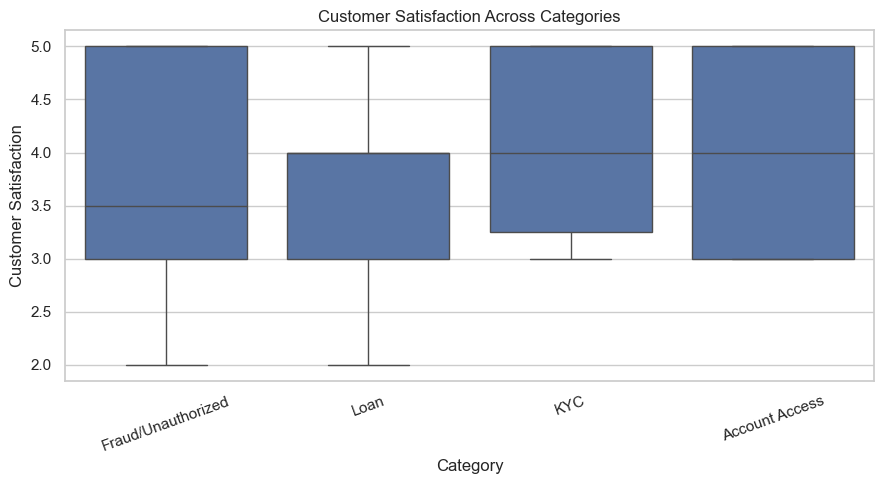

In [62]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="category",
    y="customer_satisfaction"
)

plt.title("Customer Satisfaction Across Categories")
plt.xlabel("Category")
plt.ylabel("Customer Satisfaction")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

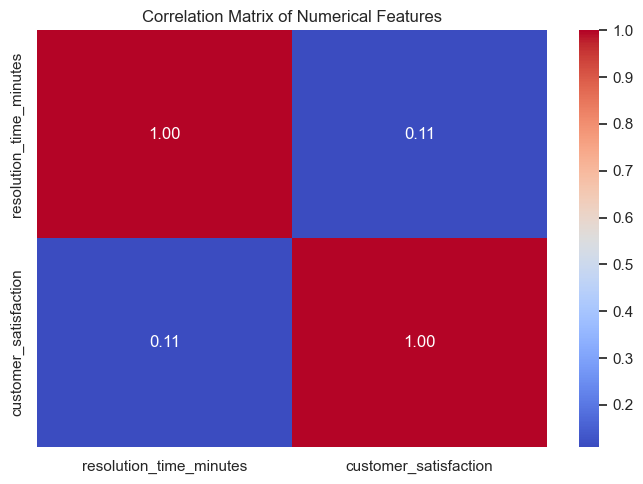

In [63]:
numeric_columns = [
    "resolution_time_minutes",
    "customer_satisfaction"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [64]:
intent_df = df[["query_text", "category"]].copy()

print(intent_df.head())
print(intent_df.shape)

                                          query_text            category
0  I see a transaction of ₹999 I didn't make on 2...  Fraud/Unauthorized
1  I see a transaction of ₹500 I didn't make on 1...  Fraud/Unauthorized
2  I see a transaction of ₹25,000 I didn't make o...  Fraud/Unauthorized
3  I see a transaction of ₹999 I didn't make on 1...  Fraud/Unauthorized
4  I see a transaction of ₹25,000 I didn't make o...  Fraud/Unauthorized
(200, 2)


In [65]:
intent_df2 = pd.read_csv(r"C:\Users\shikh\OneDrive\Desktop\AI_Banking_system\Data\synthetic_banking_queries_400.csv")
intent_df2.head(5)

,query_text,category
0,My KYC documents were rejected. What should I do?,KYC
1,My account is showing a negative balance even ...,Account Access
2,My credit card was used online without my know...,Fraud/Unauthorized
3,I received an OTP for a transaction I never in...,Fraud/Unauthorized
4,I want to add a joint account holder.,Account Access


In [66]:
intent_df = pd.concat([intent_df, intent_df2], ignore_index=True)

In [67]:
intent_df.shape

(600, 2)

In [68]:
import re
import pandas as pd

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Contractions ko normalize karo
    contractions = {
        "didn't": "did not",
        "can't": "can not",
        "couldn't": "could not",
        "won't": "will not",
        "wouldn't": "would not",
        "isn't": "is not",
        "wasn't": "was not",
        "aren't": "are not",
        "don't": "do not",
        "doesn't": "does not",
        "haven't": "have not",
        "hasn't": "has not"
    }

    for contraction, replacement in contractions.items():
        text = text.replace(contraction, replacement)

    # URLs remove
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Email remove
    text = re.sub(r'\S+@\S+', ' ', text)

    # Currency amounts remove
    # ₹999, ₹25,000, Rs 500, INR 1000 etc.
    text = re.sub(r'₹\s?[\d,]+', ' ', text)
    text = re.sub(r'\b(rs|inr)\.?\s?[\d,]+\b', ' ', text)

    # Remaining numbers remove
    text = re.sub(r'\d+', ' ', text)

    # Special characters remove
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Extra spaces remove
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [69]:
intent_df["cleaned_query"] = intent_df["query_text"].apply(clean_text)

In [70]:
intent_df

,query_text,category,cleaned_query
0,I see a transaction of ₹999 I didn't make on 2...,Fraud/Unauthorized,i see a transaction of i did not make on apr
1,I see a transaction of ₹500 I didn't make on 1...,Fraud/Unauthorized,i see a transaction of i did not make on sep
2,"I see a transaction of ₹25,000 I didn't make o...",Fraud/Unauthorized,i see a transaction of i did not make on dec
3,I see a transaction of ₹999 I didn't make on 1...,Fraud/Unauthorized,i see a transaction of i did not make on may
4,"I see a transaction of ₹25,000 I didn't make o...",Fraud/Unauthorized,i see a transaction of i did not make on jan
...,...,...,...
595,I received an OTP for a transaction I never in...,Fraud/Unauthorized,i received an otp for a transaction i never in...
596,I need to reset my internet banking login cred...,Account Access,i need to reset my internet banking login cred...
597,My loan application is still under review. Wha...,Loan,my loan application is still under review what...
598,I want to know the remaining tenure of my loan.,Loan,i want to know the remaining tenure of my loan


In [71]:
X = intent_df["cleaned_query"]
y = intent_df["category"]

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (480,)
Testing data: (120,)


In [74]:
print(y_train.value_counts())
print(y_test.value_counts())

category
Account Access        120
Loan                  120
Fraud/Unauthorized    120
KYC                   120
Name: count, dtype: int64
category
Fraud/Unauthorized    30
Account Access        30
KYC                   30
Loan                  30
Name: count, dtype: int64


In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [76]:
print("X_train:", X_train_tfidf.shape)
print("X_test:", X_test_tfidf.shape)

X_train: (480, 935)
X_test: (120, 935)


In [77]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [78]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

['Fraud/Unauthorized' 'Account Access' 'KYC' 'Loan' 'KYC' 'Loan'
 'Fraud/Unauthorized' 'Loan' 'Loan' 'KYC']


In [79]:
print("Actual:")
print(y_test.head(10).values)

print("\nPredicted:")
print(y_pred[:10])

Actual:
['Fraud/Unauthorized' 'Account Access' 'KYC' 'Loan' 'KYC' 'Loan'
 'Fraud/Unauthorized' 'Loan' 'Loan' 'KYC']

Predicted:
['Fraud/Unauthorized' 'Account Access' 'KYC' 'Loan' 'KYC' 'Loan'
 'Fraud/Unauthorized' 'Loan' 'Loan' 'KYC']


In [80]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                    precision    recall  f1-score   support

    Account Access       1.00      1.00      1.00        30
Fraud/Unauthorized       1.00      1.00      1.00        30
               KYC       1.00      1.00      1.00        30
              Loan       1.00      1.00      1.00        30

          accuracy                           1.00       120
         macro avg       1.00      1.00      1.00       120
      weighted avg       1.00      1.00      1.00       120



Testing of the model

In [82]:
new_query = ["I see a transaction I did not make"]

In [83]:
new_query_tfidf = tfidf.transform(new_query)

In [84]:
prediction = model.predict(new_query_tfidf)

print("Predicted Category:", prediction[0])

Predicted Category: Fraud/Unauthorized


In [85]:
new_queries = [
    "Someone used my debit card without my permission",
    "I want to know the status of my home loan",
    "My KYC verification is still pending",
    "I cannot login to my internet banking"
]

new_queries_tfidf = tfidf.transform(new_queries)

predictions = model.predict(new_queries_tfidf)

for query, prediction in zip(new_queries, predictions):
    print("Query:", query)
    print("Prediction:", prediction)
    print("-" * 50)

Query: Someone used my debit card without my permission
Prediction: Fraud/Unauthorized
--------------------------------------------------
Query: I want to know the status of my home loan
Prediction: Loan
--------------------------------------------------
Query: My KYC verification is still pending
Prediction: KYC
--------------------------------------------------
Query: I cannot login to my internet banking
Prediction: Account Access
--------------------------------------------------


In [86]:
unseen_queries = [
    "My card was stolen and someone has been spending money from it",
    "Can you tell me when my mortgage application will be approved?",
    "The bank is asking me to submit my identity documents again",
    "I am locked out of my mobile banking account",
    "There is a payment on my statement that I have never made",
    "How much longer will my personal loan application take?",
    "Why is my identity verification not getting completed?",
    "I forgot the password for my online bank account",
    "Someone transferred money from my account without asking me",
    "I need to know why my loan has not been disbursed yet",
    "My Aadhaar verification is failing",
    "The banking app keeps rejecting my login"
]

In [87]:
# 1. Clean unseen queries
cleaned_queries = [clean_text(q) for q in unseen_queries]

# 2. Convert using already fitted TF-IDF
queries_tfidf = tfidf.transform(cleaned_queries)

# 3. Predict
predictions = model.predict(queries_tfidf)

# 4. Display
for query, prediction in zip(unseen_queries, predictions):
    print("Query:", query)
    print("Prediction:", prediction)
    print("-" * 60)

Query: My card was stolen and someone has been spending money from it
Prediction: Fraud/Unauthorized
------------------------------------------------------------
Query: Can you tell me when my mortgage application will be approved?
Prediction: Loan
------------------------------------------------------------
Query: The bank is asking me to submit my identity documents again
Prediction: KYC
------------------------------------------------------------
Query: I am locked out of my mobile banking account
Prediction: Account Access
------------------------------------------------------------
Query: There is a payment on my statement that I have never made
Prediction: Fraud/Unauthorized
------------------------------------------------------------
Query: How much longer will my personal loan application take?
Prediction: Loan
------------------------------------------------------------
Query: Why is my identity verification not getting completed?
Prediction: KYC
------------------------------

In [88]:
import joblib
import os

# models folder create karo
os.makedirs("models", exist_ok=True)

# Model save
joblib.dump(model, "models/banking_intent_model.pkl")

# TF-IDF vectorizer save
joblib.dump(tfidf, "models/banking_intent_tfidf.pkl")

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!
